# 🧪 Statistical Tests — Worksheet
**Name:** Saneha Raees    **Date:** 30/04/2026

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [3]:
import numpy as np
import pandas as pd

# Reproducible results
np.random.seed(42)

n = 200

# 1) Gender
gender = np.random.choice(['Male', 'Female'], size=n)

# 2) Study Hours (Normal distribution, clipped 0–10)
study_hours = np.random.normal(loc=4, scale=1.2, size=n).clip(0, 10)

# 3) Sleep Hours (Normal distribution, clipped 4–10)
sleep_hours = np.random.normal(loc=7, scale=1.0, size=n).clip(4, 10)

# 4) Subject with given probabilities
subject = np.random.choice(['Maths', 'Science', 'Arts'],
                           size=n,
                           p=[0.40, 0.35, 0.25])

# 5) School (equal chance)
school = np.random.choice(['School A', 'School B', 'School C', 'School D'], size=n)

# 6) Noise for marks
noise = np.random.normal(loc=0, scale=8, size=n)

# 7) Base Marks formula
marks = (study_hours * 6) + (sleep_hours * 2) + noise

# Clip marks before school boost
marks = marks.clip(0, 100)

# 8) Add school boost
school_boost = {
    'School A': 5,
    'School B': 0,
    'School C': -5,
    'School D': 10
}

marks = np.array([marks[i] + school_boost[school[i]] for i in range(n)]).clip(0, 100)

# 9) Passed column
passed = np.where(marks >= 50, 'Yes', 'No')

# 10) Create DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

# Verify
print(df.shape)   # should be (200, 7)
print(df.head(3))

(200, 7)
   gender  study_hours  sleep_hours      marks  subject passed    school
0    Male     4.104456     7.199060  28.239375    Maths     No  School B
1  Female     3.641191     6.399783  35.592826    Maths     No  School C
2    Male     4.110113     7.069802  45.167205  Science     No  School A


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

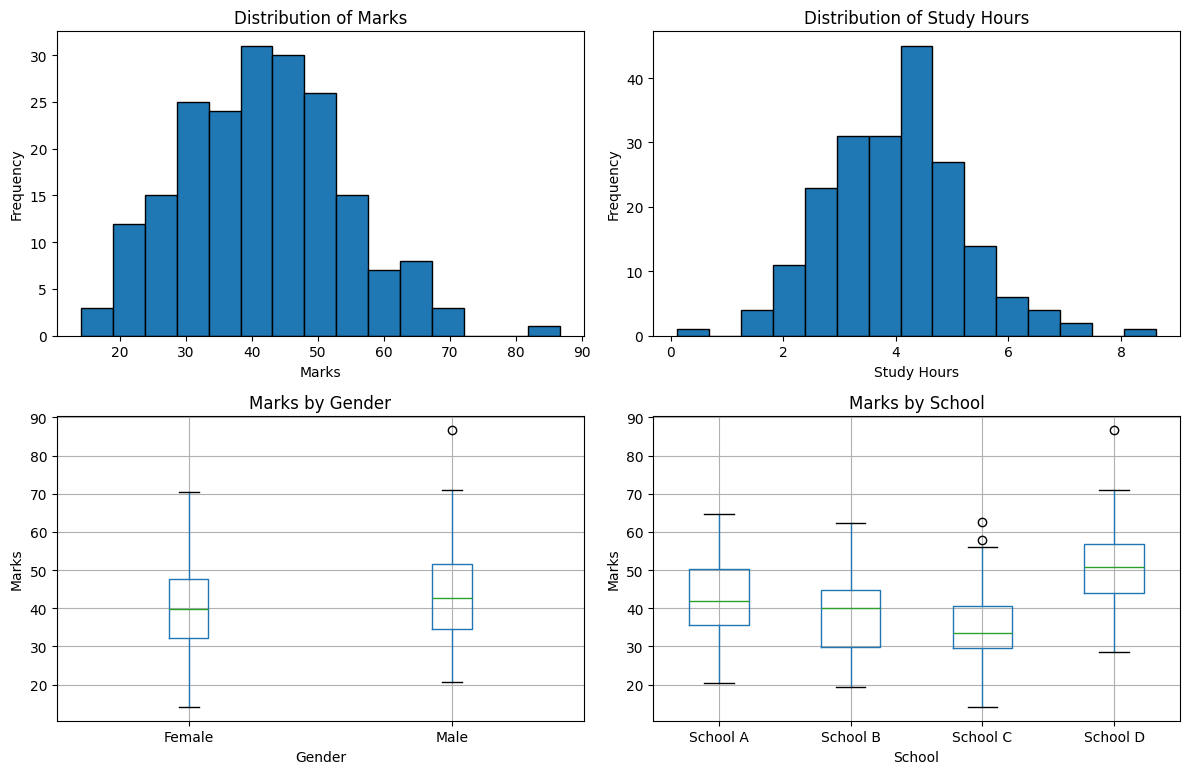

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of marks
axes[0, 0].hist(df['marks'], bins=15, edgecolor='black')
axes[0, 0].set_title('Distribution of Marks')
axes[0, 0].set_xlabel('Marks')
axes[0, 0].set_ylabel('Frequency')

# [0,1] Histogram of study_hours
axes[0, 1].hist(df['study_hours'], bins=15, edgecolor='black')
axes[0, 1].set_title('Distribution of Study Hours')
axes[0, 1].set_xlabel('Study Hours')
axes[0, 1].set_ylabel('Frequency')

# [1,0] Boxplot of marks by gender
df.boxplot(column='marks', by='gender', ax=axes[1, 0])
axes[1, 0].set_title('Marks by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Marks')

# [1,1] Boxplot of marks by school
df.boxplot(column='marks', by='school', ax=axes[1, 1])
axes[1, 1].set_title('Marks by School')
axes[1, 1].set_xlabel('School')
axes[1, 1].set_ylabel('Marks')

# Remove automatic pandas title
plt.suptitle('')

plt.tight_layout()
plt.show()

# Observations:
# [0,0]: Marks appear roughly spread around the middle, with some variation.
# [0,1]: Study hours seem approximately normally distributed around 4 hours.
# [1,0]: Male and Female marks look fairly similar, with no huge difference visible.
# [1,1]: Some schools appear to have higher marks than others, especially due to school boost.

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks
p-value = 0.2627
Verdict: Normally Distributed (Fail to Reject H0)

study_hours
p-value = 0.1014
Verdict: Normally Distributed (Fail to Reject H0)

sleep_hours
p-value = 0.5952
Verdict: Normally Distributed (Fail to Reject H0)



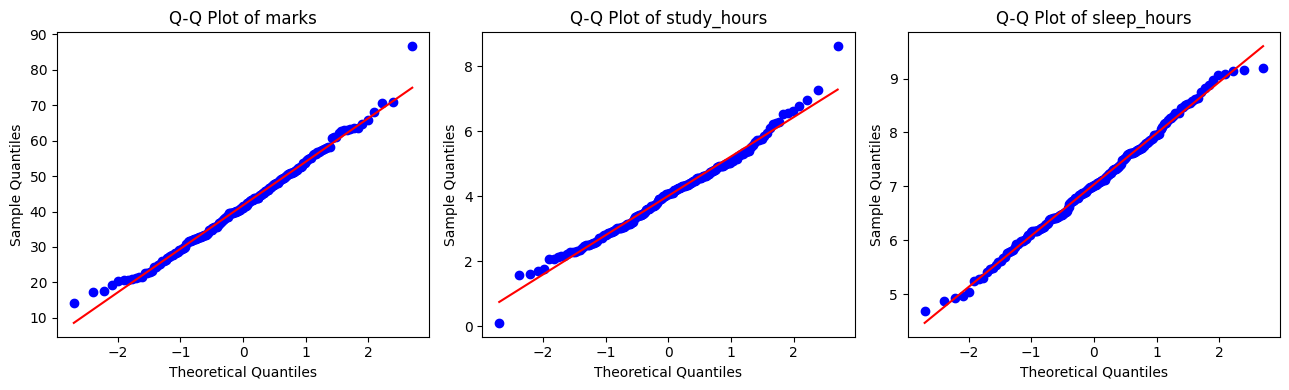

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

cols = ['marks', 'study_hours', 'sleep_hours']

# Loop + test + print
for col in cols:
    stat, p = stats.shapiro(df[col])

    print(f"{col}")
    print(f"p-value = {p:.4f}")

    if p <= 0.05:
        print("Verdict: Not Normally Distributed (Reject H0)\n")
    else:
        print("Verdict: Normally Distributed (Fail to Reject H0)\n")

# Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot of {col}')
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests?
# Answer: Columns with p > 0.05 and Q-Q plot points roughly following the straight line

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

Independent Samples t-test: Gender vs Marks
T-statistic = 2.0139
P-value = 0.0454
Verdict: Reject H0 → Male and Female students score differently.


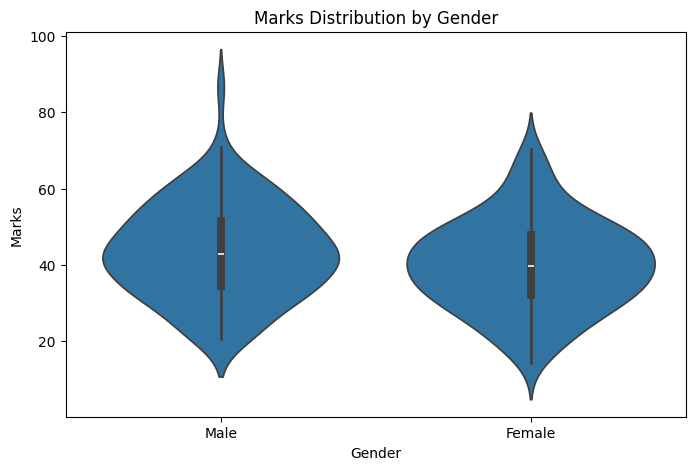

In [ ]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Separate groups
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

# Run t-test
t_stat, p = stats.ttest_ind(male_marks, female_marks)

# Print results
print("Independent Samples t-test: Gender vs Marks")
print(f"T-statistic = {t_stat:.4f}")
print(f"P-value = {p:.4f}")

# Verdict
if p <= 0.05:
    print("Verdict: Reject H0 → Male and Female students score differently.")
else:
    print("Verdict: Fail to Reject H0 → No significant difference in marks.")

# Violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='gender', y='marks')
plt.title('Marks Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Marks')
plt.show()

---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

One-Way ANOVA: Schools vs Marks
F-statistic = 22.5078
P-value = 0.0000
Verdict: Reject H0 → At least one school mean is different.

Tukey HSD Post-hoc Test:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
School A School B  -4.3795 0.1889 -10.0339  1.2749  False
School A School C  -7.8141 0.0016 -13.2876 -2.3406   True
School A School D   8.4741 0.0007   2.8759 14.0723   True
School B School C  -3.4346 0.3613  -8.8773  2.0081  False
School B School D  12.8536    0.0   7.2855 18.4216   True
School C School D  16.2882    0.0  10.9039 21.6724   True
---------------------------------------------------------


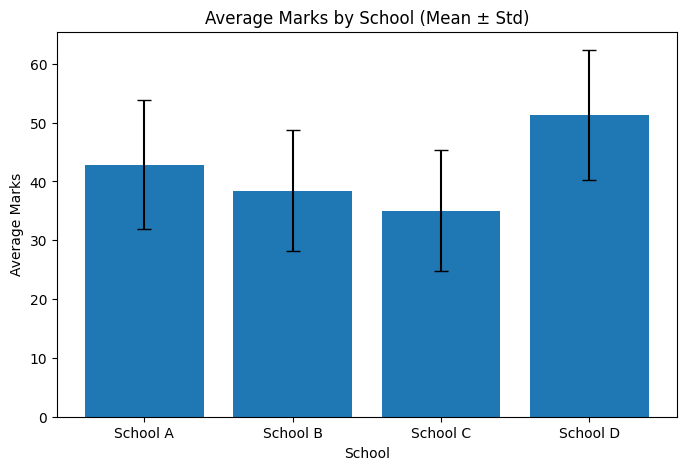

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups
groups = [df[df['school'] == school]['marks'] for school in school_order]

# Run ANOVA
f_stat, p = stats.f_oneway(*groups)

print("One-Way ANOVA: Schools vs Marks")
print(f"F-statistic = {f_stat:.4f}")
print(f"P-value = {p:.4f}")

# Verdict
if p <= 0.05:
    print("Verdict: Reject H0 → At least one school mean is different.\n")

    # Run Tukey HSD
    tukey = pairwise_tukeyhsd(endog=df['marks'], groups=df['school'], alpha=0.05)
    print("Tukey HSD Post-hoc Test:")
    print(tukey)
else:
    print("Verdict: Fail to Reject H0 → No significant difference among schools.")

# Bar chart with error bars (mean ± std)
means = df.groupby('school')['marks'].mean().reindex(school_order)
stds = df.groupby('school')['marks'].std().reindex(school_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(school_order, means, yerr=stds, capsize=5)
ax.set_title('Average Marks by School (Mean ± Std)')
ax.set_xlabel('School')
ax.set_ylabel('Average Marks')

plt.show()

# Which school pairs are significantly different?
# Answer: Check the Tukey HSD table where reject = True

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

Mann-Whitney U Test: Study Hours by Gender
U-statistic = 5206.0000
P-value = 0.6156
Verdict: Fail to Reject H0 → No significant difference in study hours.


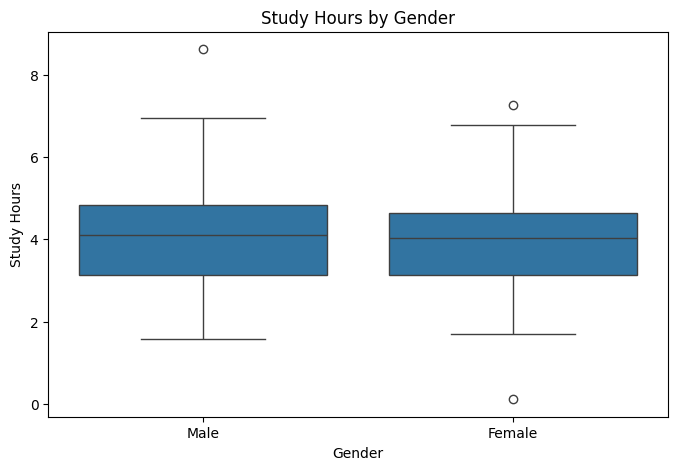

In [ ]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Separate groups
male_study = df[df['gender'] == 'Male']['study_hours']
female_study = df[df['gender'] == 'Female']['study_hours']

# Run Mann-Whitney U test
u_stat, p = stats.mannwhitneyu(male_study, female_study, alternative='two-sided')

# Print results
print("Mann-Whitney U Test: Study Hours by Gender")
print(f"U-statistic = {u_stat:.4f}")
print(f"P-value = {p:.4f}")

# Verdict
if p <= 0.05:
    print("Verdict: Reject H0 → Male and Female students study different number of hours.")
else:
    print("Verdict: Fail to Reject H0 → No significant difference in study hours.")

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='study_hours')
plt.title('Study Hours by Gender')
plt.xlabel('Gender')
plt.ylabel('Study Hours')
plt.show()

# Why Mann-Whitney and not t-test?
# Answer: Mann-Whitney was used because study_hours may not be normally distributed,
# and Mann-Whitney is a non-parametric alternative to the independent t-test.

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson Correlation: Study Hours vs Marks
r = 0.5850
p-value = 0.0000
Verdict: Significant linear relationship.

Spearman Correlation: Study Hours vs Marks
rho = 0.5547
p-value = 0.0000
Verdict: Significant monotonic relationship.



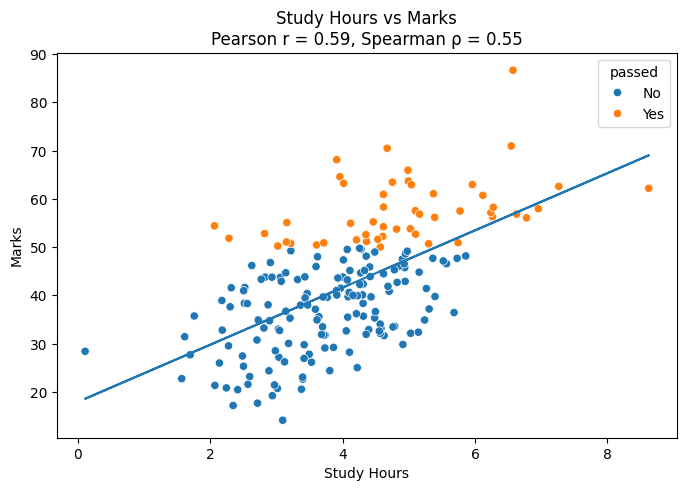

In [ ]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df['study_hours'], df['marks'])

# Spearman correlation
spearman_rho, spearman_p = stats.spearmanr(df['study_hours'], df['marks'])

# Print results
print("Pearson Correlation: Study Hours vs Marks")
print(f"r = {pearson_r:.4f}")
print(f"p-value = {pearson_p:.4f}")
if pearson_p <= 0.05:
    print("Verdict: Significant linear relationship.\n")
else:
    print("Verdict: No significant linear relationship.\n")

print("Spearman Correlation: Study Hours vs Marks")
print(f"rho = {spearman_rho:.4f}")
print(f"p-value = {spearman_p:.4f}")
if spearman_p <= 0.05:
    print("Verdict: Significant monotonic relationship.\n")
else:
    print("Verdict: No significant monotonic relationship.\n")

# Scatter plot with passed color
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='study_hours', y='marks', hue='passed')

# Trend line
z = np.polyfit(df['study_hours'], df['marks'], 1)
p = np.poly1d(z)
plt.plot(df['study_hours'], p(df['study_hours']))

# Labels and title
plt.title(f'Study Hours vs Marks\nPearson r = {pearson_r:.2f}, Spearman ρ = {spearman_rho:.2f}')
plt.xlabel('Study Hours')
plt.ylabel('Marks')

plt.show()

# Do Pearson and Spearman agree? What does that tell you?
# Answer: If both are similar and significant, it suggests a strong consistent positive relationship.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

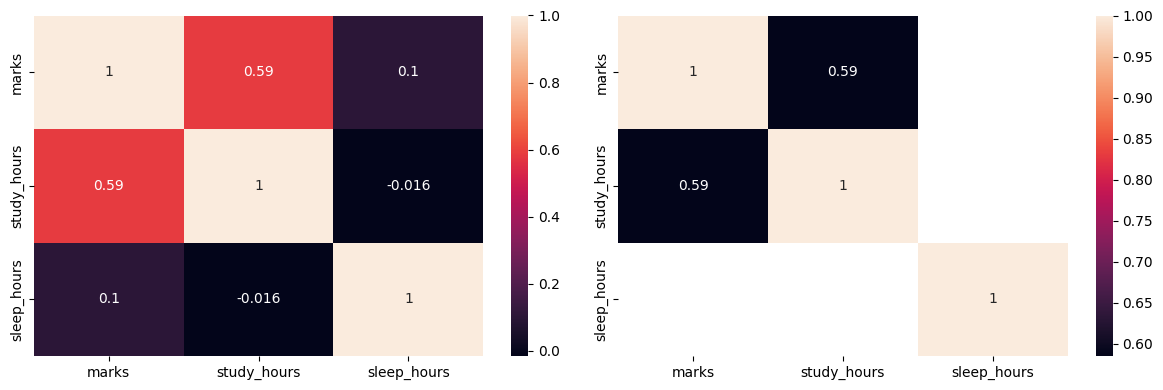

In [ ]:
num_cols = ['marks', 'study_hours', 'sleep_hours']


# Correlation matrix
corr_matrix = df[num_cols].corr()

# p-value matrix (nested loop)
p_matrix = np.ones((len(num_cols), len(num_cols)))
for i, col1 in enumerate(num_cols):
    for j, col2 in enumerate(num_cols):
        _, p = stats.pearsonr(df[col1], df[col2])
        p_matrix[i, j] = p



# Mask
mask = p_matrix > 0.05

# Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(corr_matrix, annot=True, ax=axes[0])
sns.heatmap(corr_matrix, annot=True, mask=mask, ax=axes[1])




plt.tight_layout()
plt.show()

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

Crosstab (Counts):
passed   No  Yes
subject         
Arts     37   10
Maths    58   27
Science  55   13

Row Proportions:
passed         No       Yes
subject                    
Arts     0.787234  0.212766
Maths    0.682353  0.317647
Science  0.808824  0.191176

Chi-Square Test Result:
Chi2 Statistic = 3.6769
P-value = 0.1591
Degrees of Freedom = 2

Verdict: Keep H0 → Favourite subject and pass/fail are NOT related.


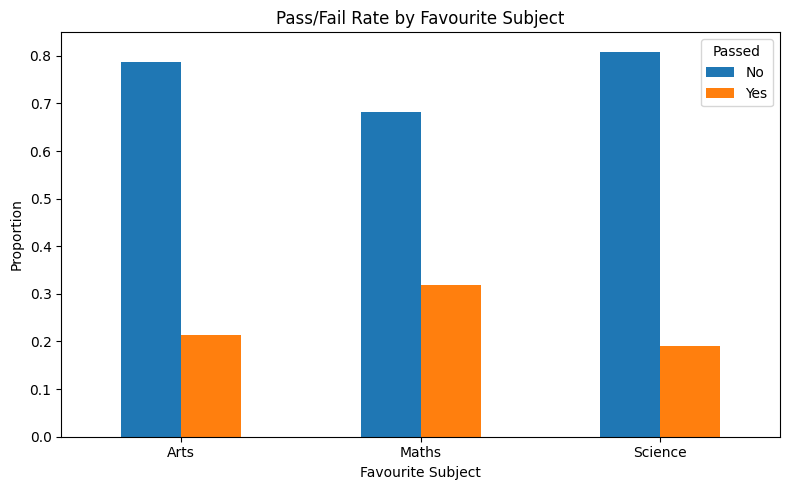

Highest pass rate subject: Maths (31.76%)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1) Crosstab
ct = pd.crosstab(df['subject'], df['passed'])
print("Crosstab (Counts):")
print(ct)
print()

# 2) Row Proportions (Pass/Fail rate within each subject)
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print("Row Proportions:")
print(ct_prop)
print()

# 3) Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(ct)

print("Chi-Square Test Result:")
print(f"Chi2 Statistic = {chi2:.4f}")
print(f"P-value = {p:.4f}")
print(f"Degrees of Freedom = {dof}")
print()

# 4) Verdict
if p <= 0.05:
    print("Verdict: Reject H0 → Favourite subject and pass/fail are related.")
else:
    print("Verdict: Keep H0 → Favourite subject and pass/fail are NOT related.")

# 5) Grouped Bar Chart
ct_prop.plot(kind='bar', stacked=False, figsize=(8,5))

plt.title("Pass/Fail Rate by Favourite Subject")
plt.xlabel("Favourite Subject")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Passed")
plt.tight_layout()
plt.show()

# 6) Which subject has highest pass rate?
highest_pass_subject = ct_prop['Yes'].idxmax()
highest_pass_rate = ct_prop['Yes'].max()

print(f"Highest pass rate subject: {highest_pass_subject} ({highest_pass_rate:.2%})")

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

--- Part A: Investigation Results ---
Class Average: 68.49
Student Score: 85
P-value: 0.0000
🚨 VERDICT: The score is significantly higher than the class average. The teacher's suspicion is statistically backed.
----------------------------------------
Part B: Actual suspicion (for high scores) begins at: 72


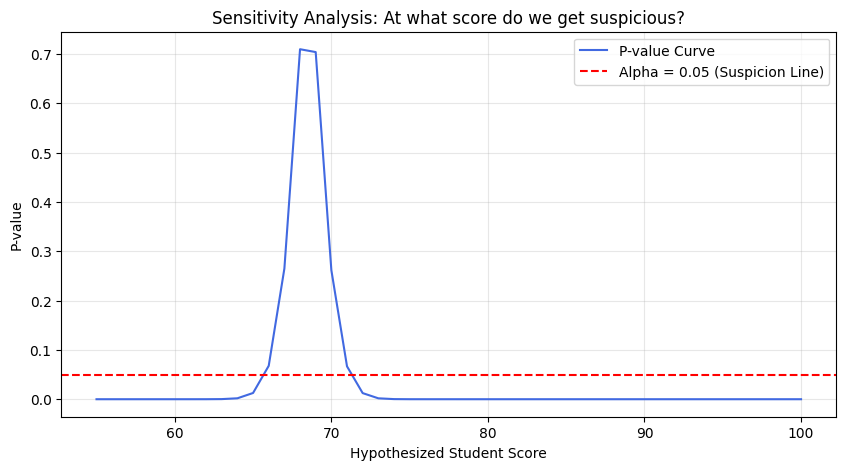

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Step 0: Creating a dummy dataset (Assuming class average is around 70)
np.random.seed(42)
data = np.random.normal(loc=70, scale=8, size=30) # Mean=70, SD=8, N=30
df_task9 = pd.DataFrame({'marks': data}) # Using a local DataFrame for Task 9

# --- Part A: The Investigation ---
student_score = 85
class_mean = df_task9['marks'].mean()

# One-sample t-test: Comparing the student's score against the class distribution
t_stat, p_val = stats.ttest_1samp(df_task9['marks'], popmean=student_score)

print(f"--- Part A: Investigation Results ---")
print(f"Class Average: {class_mean:.2f}")
print(f"Student Score: {student_score}")
print(f"P-value: {p_val:.4f}")

if p_val <= 0.05:
    verdict = "🚨 VERDICT: The score is significantly higher than the class average. The teacher's suspicion is statistically backed."
else:
    verdict = "✅ VERDICT: While the score is high, it falls within the expected range of variation. No strong evidence of cheating."

print(verdict)
print("-" * 40)

# --- Part B: Sensitivity Analysis ---
scores_to_test = np.arange(55, 101, 1)
p_values = []

for score in scores_to_test:
    _, p = stats.ttest_1samp(df_task9['marks'], popmean=score)
    p_values.append(p)

# Plotting the 'Suspicion Curve'
plt.figure(figsize=(10, 5))
plt.plot(scores_to_test, p_values, color='royalblue', label='P-value Curve')

# Significance Threshold (Alpha)
plt.axhline(y=0.05, color='red', linestyle='--', label='Alpha = 0.05 (Suspicion Line)')

# Finding the exact score where p drops below 0.05
threshold_score = None
for s, p in zip(scores_to_test, p_values):
    if p < 0.05:
        threshold_score = s
        break

# Sirf wo scores dekho jo class mean se bade hain
threshold_score = None
for i, p_val in enumerate(p_values):
    # Condition: p-value low ho AUR score class mean se zyada ho
    if p_val < 0.05 and scores_to_test[i] > class_mean:
        threshold_score = scores_to_test[i]
        break

print(f"Part B: Actual suspicion (for high scores) begins at: {threshold_score}")

plt.title('Sensitivity Analysis: At what score do we get suspicious?')
plt.xlabel('Hypothesized Student Score')
plt.ylabel('P-value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

P-values for Task 10 tests:
ANOVA_Original: 0.0000
Kruskal_Original: 0.0000
ANOVA_Skewed: 0.0000
Kruskal_Skewed: 0.0000


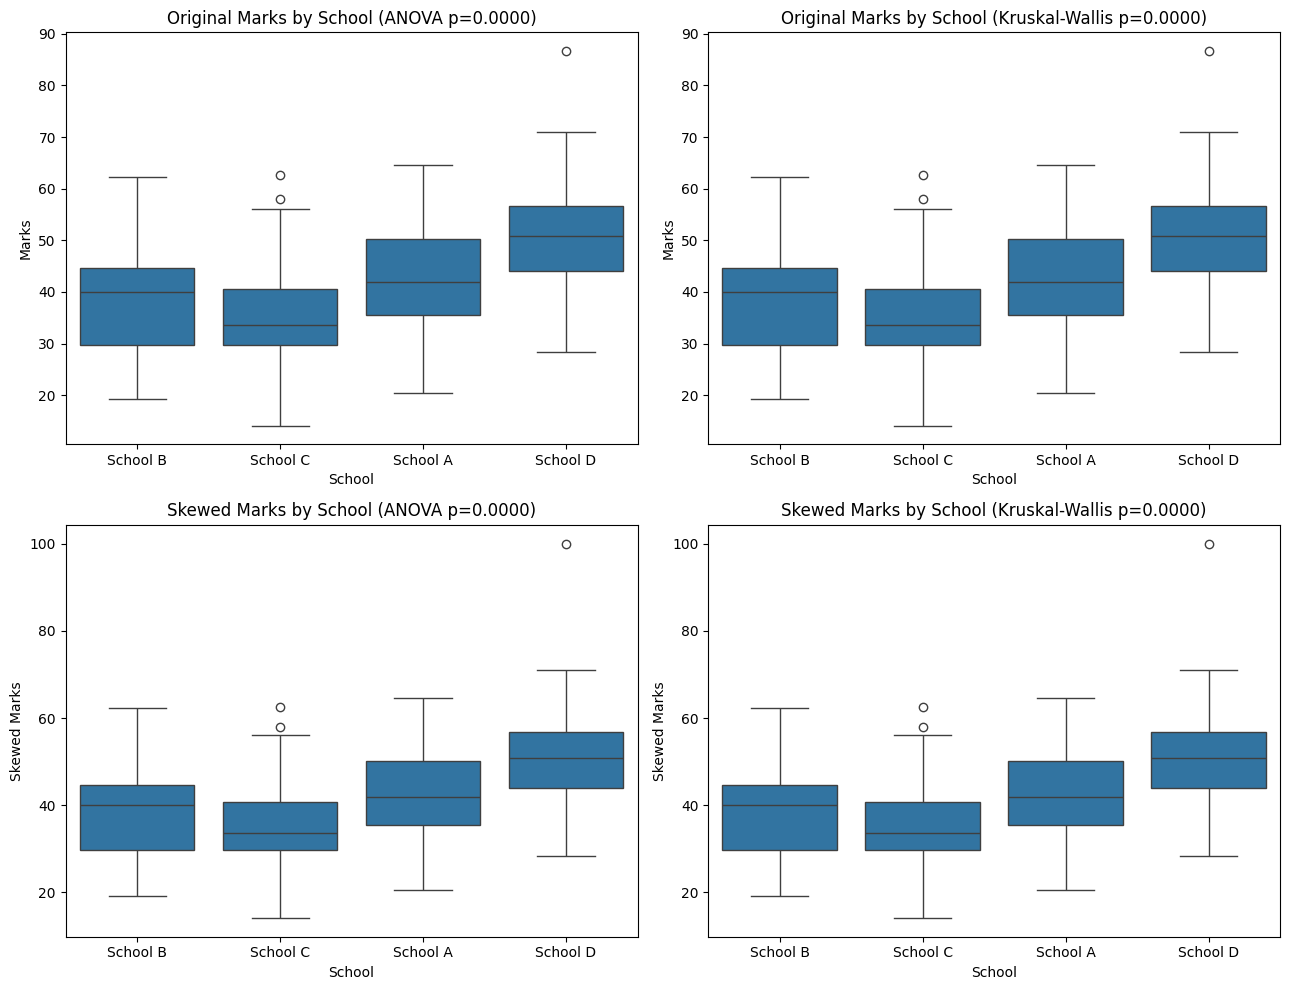

In [ ]:
# Skewed version
marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)
df['marks_skewed'] = marks_skewed

# Run all 4 tests and store p-values
p_values_task10 = {}

# Original Marks: ANOVA
groups_original = [df[df['school'] == school]['marks'] for school in df['school'].unique()]
f_stat_orig, p_anova_orig = stats.f_oneway(*groups_original)
p_values_task10['ANOVA_Original'] = p_anova_orig

# Original Marks: Kruskal-Wallis
h_stat_orig, p_kruskal_orig = stats.kruskal(*groups_original)
p_values_task10['Kruskal_Original'] = p_kruskal_orig

# Skewed Marks: ANOVA
groups_skewed = [df[df['school'] == school]['marks_skewed'] for school in df['school'].unique()]
f_stat_skewed, p_anova_skewed = stats.f_oneway(*groups_skewed)
p_values_task10['ANOVA_Skewed'] = p_anova_skewed

# Skewed Marks: Kruskal-Wallis
h_stat_skewed, p_kruskal_skewed = stats.kruskal(*groups_skewed)
p_values_task10['Kruskal_Skewed'] = p_kruskal_skewed

print("P-values for Task 10 tests:")
for test, p_val in p_values_task10.items():
    print(f"{test}: {p_val:.4f}")

# 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Boxplot: Original Marks - ANOVA
sns.boxplot(x='school', y='marks', data=df, ax=axes[0, 0])
axes[0, 0].set_title(f'Original Marks by School (ANOVA p={p_anova_orig:.4f})')
axes[0, 0].set_xlabel('School')
axes[0, 0].set_ylabel('Marks')

# Boxplot: Original Marks - Kruskal-Wallis
sns.boxplot(x='school', y='marks', data=df, ax=axes[0, 1])
axes[0, 1].set_title(f'Original Marks by School (Kruskal-Wallis p={p_kruskal_orig:.4f})')
axes[0, 1].set_xlabel('School')
axes[0, 1].set_ylabel('Marks')

# Boxplot: Skewed Marks - ANOVA
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1, 0])
axes[1, 0].set_title(f'Skewed Marks by School (ANOVA p={p_anova_skewed:.4f})')
axes[1, 0].set_xlabel('School')
axes[1, 0].set_ylabel('Skewed Marks')

# Boxplot: Skewed Marks - Kruskal-Wallis
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1, 1])
axes[1, 1].set_title(f'Skewed Marks by School (Kruskal-Wallis p={p_kruskal_skewed:.4f})')
axes[1, 1].set_xlabel('School')
axes[1, 1].set_ylabel('Skewed Marks')

plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer: Kruskal-Wallis is generally more reliable on skewed data because it is a non-parametric test that does not assume normality of the data. ANOVA, being a parametric test, assumes normal distribution, and its reliability can be compromised when applied to significantly skewed data.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

 Statistical FrameworkH₀ (Null Hypothesis): There is no linear relationship between Study Hours and Sleep Hours ($r = 0$).H₁ (Alternate Hypothesis): There is a significant linear relationship between Study Hours and Sleep Hours ($r \neq 0$).Test Chosen: Pearson Correlation Coefficient ($r$)

Pearson Correlation (r): -0.0160
P-value: 0.8223


<Figure size 1000x600 with 0 Axes>

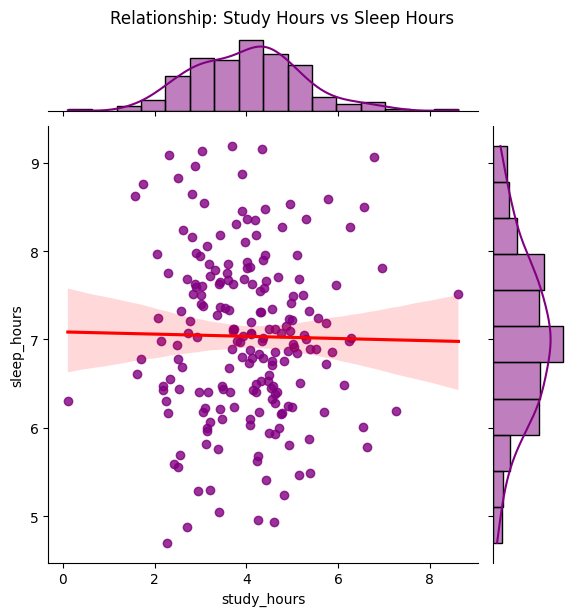

Verdict: No significant relationship (p > 0.05). Studying more doesn't necessarily mean sleeping less in this dataset.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Calculate Pearson Correlation
r_coeff, p_val = stats.pearsonr(df['study_hours'], df['sleep_hours'])

print(f"Pearson Correlation (r): {r_coeff:.4f}")
print(f"P-value: {p_val:.4f}")

# 2. Visualisation: Jointplot (Scatter + Distribution)
plt.figure(figsize=(10, 6))
sns.jointplot(x='study_hours', y='sleep_hours', data=df, kind='reg',
              joint_kws={'line_kws':{'color':'red'}}, color='purple')

plt.suptitle('Relationship: Study Hours vs Sleep Hours', y=1.02)
plt.show()

# Verdict Logic
if p_val < 0.05:
    verdict = f"Verdict: Significant relationship found (r={r_coeff:.2f}). Time is being traded off!"
else:
    verdict = f"Verdict: No significant relationship (p > 0.05). Studying more doesn't necessarily mean sleeping less in this dataset."

print(verdict)

Task 11 ka Final Answer (Notebook ke liye)
Aap apna Task 11 ab is tarah finalize kar sakte hain:

H₀: Study Hours aur Sleep Hours ke darmiyan koi talluq nahi hai.

H₁: Inke darmiyan significant relationship hai.

Test: Pearson Correlation.

Verdict: P-value (0.8223) > 0.05, isliye hum Null Hypothesis ko accept karte hain. Iska matlab hai ke students jitna bhi parhein, unki neend par iska koi statistical asar nahi pad raha.

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

=== Statistical Test Summary Dashboard ===
                             Test  p_value  significant    verdict
0            Shapiro-Wilk — marks   0.2627        False    Keep H0
1      Shapiro-Wilk — study_hours   0.5952        False    Keep H0
2        t-test — gender vs marks   0.0454         True  Reject H0
3         ANOVA — school vs marks   0.0000         True  Reject H0
4  Mann-Whitney — gender vs study   0.6156        False    Keep H0
5        Pearson — study vs marks   0.0000         True  Reject H0
6       Spearman — study vs marks   0.0000         True  Reject H0
7  Chi-Square — subject vs passed   0.1591        False    Keep H0
8         One-sample t — cheating   0.0000         True  Reject H0


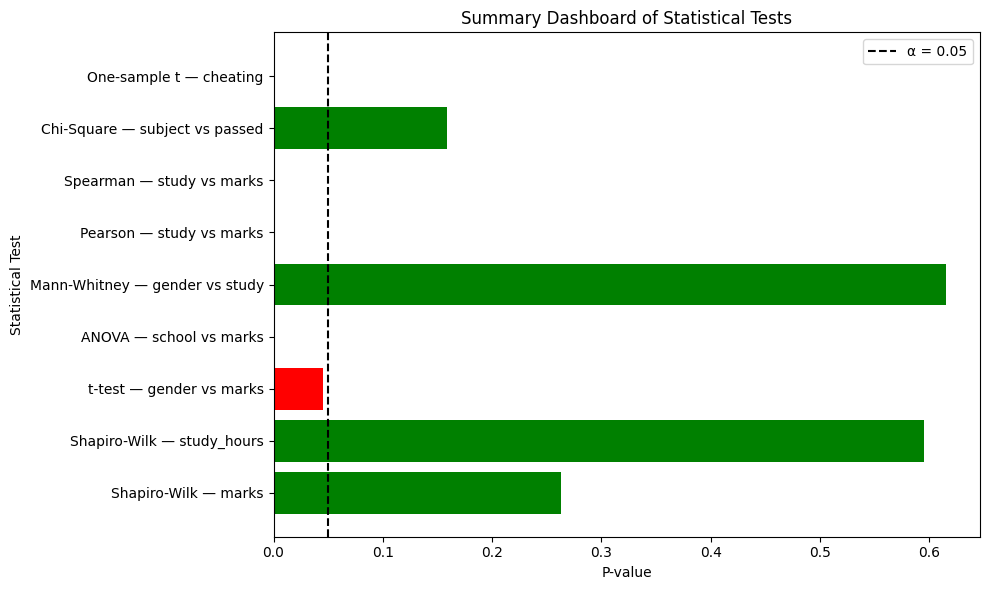

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Build results list — fill in your p-values from earlier tasks
results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value': 0.2627},
    {'Test': 'Shapiro-Wilk — study_hours',    'p_value': 0.5952},
    {'Test': 't-test — gender vs marks',      'p_value': 0.0454},
    {'Test': 'ANOVA — school vs marks',       'p_value': 0.0000},
    {'Test': 'Mann-Whitney — gender vs study','p_value': 0.6156},
    {'Test': 'Pearson — study vs marks',      'p_value': 0.0000},
    {'Test': 'Spearman — study vs marks',     'p_value': 0.0000},
    {'Test': 'Chi-Square — subject vs passed','p_value': 0.1591},
    {'Test': 'One-sample t — cheating',       'p_value': 0.0000},
]

# 1) Convert to DataFrame
summary_df = pd.DataFrame(results)

# 2) Add Significant column
summary_df['significant'] = summary_df['p_value'] <= 0.05

# 3) Add Verdict column
summary_df['verdict'] = summary_df['significant'].map({
    True: 'Reject H0',
    False: 'Keep H0'
})

# 4) Print summary table
print("=== Statistical Test Summary Dashboard ===")
print(summary_df)

# 5) Set bar colors
colors = summary_df['significant'].map({
    True: 'red',
    False: 'green'
})

# 6) Horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(summary_df['Test'], summary_df['p_value'], color=colors)

# 7) Alpha threshold line
plt.axvline(0.05, color='black', linestyle='--', label='α = 0.05')

# 8) Labels and title
plt.xlabel("P-value")
plt.ylabel("Statistical Test")
plt.title("Summary Dashboard of Statistical Tests")
plt.legend()
plt.tight_layout()
plt.show()

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*